In [45]:
#%pip install thop fvcore ptflops -q

In [46]:
# Cell: Imports & device
import os, time, math
from copy import copy

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import timm

import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report

import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [47]:
# Cell: Config - ปรับค่านี้ก่อนรัน
test_dir = "./data/test/"   # <- ปรับ path ให้ตรงกับคุณ
train_dir = "./data/train_augmented/"  # สำหรับเช็คนับไฟล์ (optional)

batch_size = 32
num_workers = 4
image_size = 224   # ปรับให้ตรงกับที่ train มา
num_classes = 5    # จำนวนคลาสจริงของคุณ
out_dir = "evaluation_output"
os.makedirs(out_dir, exist_ok=True)
os.makedirs(os.path.join(out_dir, "cm_images"), exist_ok=True)

# แก้ model_specs ให้ตรงกับพาธและ arch ของคุณ (ผมแปลง backslash -> forward slash)
model_specs = [
    {"name": "model1", "path": "transferLearning_aug/denseNet-201/densenet201_checkpoint_fold2.pt", "arch": "densenet201"},
    {"name": "model2", "path": "transferLearning_aug/efficientNetV2/efficientnetv2_checkpoint_fold2.pt", "arch": "tf_efficientnetv2_b0"},
    {"name": "model3", "path": "transferLearning_aug/mobileNetV3/mobilenetv3_large_100_checkpoint_fold2.pt", "arch": "mobilenetv3_large_100"},
    {"name": "model4", "path": "transferLearning_aug/res2net50/res2net50_checkpoint_fold3.pt", "arch": "res2net50_26w_4s"},
    {"name": "model5", "path": "transferLearning_aug/resnet50/resnet50_checkpoint_fold4.pt", "arch": "resnet50"},
]


In [48]:
# Cell: Count files in train/test (optional)
categories = [
    "ALGAL_LEAF_SPOT",
    "ALLOCARIDARA_ATTACK",
    "HEALTHY_LEAF",
    "LEAF_BLIGHT",
    "PHOMOPSIS_LEAF_SPOT"
]

print("--- Training Set File Counts ---")
for category in categories:
    dir_path = os.path.join(train_dir, category)
    if os.path.isdir(dir_path):
        print(f"{category}: {len(os.listdir(dir_path))}")
    else:
        print(f"{category}: Directory not found: {dir_path}")

print("\n--- Test Set File Counts ---")
for category in categories:
    dir_path = os.path.join(test_dir, category)
    if os.path.isdir(dir_path):
        print(f"{category}: {len(os.listdir(dir_path))}")
    else:
        print(f"{category}: Directory not found: {dir_path}")


--- Training Set File Counts ---
ALGAL_LEAF_SPOT: 1896
ALLOCARIDARA_ATTACK: 2361
HEALTHY_LEAF: 2523
LEAF_BLIGHT: 2424
PHOMOPSIS_LEAF_SPOT: 2271

--- Test Set File Counts ---
ALGAL_LEAF_SPOT: 101
ALLOCARIDARA_ATTACK: 126
HEALTHY_LEAF: 135
LEAF_BLIGHT: 129
PHOMOPSIS_LEAF_SPOT: 121


In [49]:
# Cell: Create test Dataset & DataLoader
test_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

test_dataset = datasets.ImageFolder(test_dir, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

idx_to_class = {v:k for k,v in test_dataset.class_to_idx.items()}
class_names = [idx_to_class[i] for i in range(len(idx_to_class))]
print(f"Found {len(test_dataset)} images in test set. Classes: {class_names}")


Found 612 images in test set. Classes: ['ALGAL_LEAF_SPOT', 'ALLOCARIDARA_ATTACK', 'HEALTHY_LEAF', 'LEAF_BLIGHT', 'PHOMOPSIS_LEAF_SPOT']


In [50]:
# Cell: Robust loader (safe_torch_load, extract_state_dict_from_checkpoint, build_model_and_load_weights)
import torch
import timm

def safe_torch_load(path, map_location="cpu"):
    try:
        # Try weights_only if supported (safer), else fallback
        return torch.load(path, map_location=map_location, weights_only=True)
    except TypeError:
        return torch.load(path, map_location=map_location)
    except Exception:
        return torch.load(path, map_location=map_location)

def extract_state_dict_from_checkpoint(checkpoint):
    """
    Return (extracted, is_module_flag)
    - if is_module_flag True: extracted is a torch.nn.Module
    - else: extracted is a state_dict (dict)
    """
    # 1) whole model
    if isinstance(checkpoint, torch.nn.Module):
        return checkpoint, True

    # 2) object with state_dict() (e.g., Fabric wrapper)
    if hasattr(checkpoint, "state_dict") and callable(getattr(checkpoint, "state_dict")):
        try:
            sd = checkpoint.state_dict()
            if isinstance(sd, dict):
                return sd, False
        except Exception:
            pass

    # 3) checkpoint dict with keys
    if isinstance(checkpoint, dict):
        for key in ("state_dict","model_state_dict","model","weights","params"):
            if key in checkpoint:
                candidate = checkpoint[key]
                if isinstance(candidate, dict):
                    return candidate, False
                if isinstance(candidate, torch.nn.Module):
                    return candidate, True
        # heuristics: if dict looks like state_dict
        sample_keys = list(checkpoint.keys())[:5]
        if sample_keys:
            if all(isinstance(k, str) and ("weight" in k or "bias" in k or "." in k) for k in sample_keys):
                return checkpoint, False

    # 4) common attributes pointing to model/state
    for attr in ("module","model","net","orig_mod"):
        if hasattr(checkpoint, attr):
            underlying = getattr(checkpoint, attr)
            if isinstance(underlying, torch.nn.Module):
                return underlying, True
            if isinstance(underlying, dict):
                return underlying, False

    return checkpoint, isinstance(checkpoint, torch.nn.Module)

def build_model_and_load_weights(arch, weights_path, num_classes, device):
    # create timm model if arch provided
    model = None
    if arch:
        try:
            model = timm.create_model(arch, pretrained=False, num_classes=num_classes)
        except Exception as e:
            print(f"[build] cannot create timm model '{arch}': {e}")
            model = None

    ckpt = safe_torch_load(weights_path, map_location="cpu")
    extracted, is_module = extract_state_dict_from_checkpoint(ckpt)

    # Case: whole Module
    if is_module and isinstance(extracted, torch.nn.Module):
        if model is None:
            loaded_model = extracted
        else:
            try:
                sd = extracted.state_dict()
                new_sd = {}
                for k,v in sd.items():
                    new_k = k[len("module."):] if k.startswith("module.") else k
                    new_sd[new_k] = v
                model.load_state_dict(new_sd, strict=False)
                loaded_model = model
            except Exception as e:
                print(f"[load] fallback to using module checkpoint as model: {e}")
                loaded_model = extracted

    # Case: state_dict (dict)
    elif isinstance(extracted, dict):
        sd = extracted
        new_sd = {}
        for k,v in sd.items():
            new_k = k[len("module."):] if k.startswith("module.") else k
            new_sd[new_k] = v

        if model is None:
            print("[build] No arch provided or failed: falling back to resnet18")
            model = timm.create_model('resnet18', pretrained=False, num_classes=num_classes)

        try:
            model.load_state_dict(new_sd, strict=False)
            loaded_model = model
        except Exception as e:
            try:
                # partial load by matching shapes
                model_dict = model.state_dict()
                compatible = {k: v for k, v in new_sd.items() if k in model_dict and model_dict[k].shape == v.shape}
                model_dict.update(compatible)
                model.load_state_dict(model_dict, strict=False)
                print(f"[load] Partial load: loaded {len(compatible)}/{len(model_dict)} parameters.")
                loaded_model = model
            except Exception as e2:
                raise RuntimeError(f"Failed to load weights into model: {e2}")

    else:
        # unknown: try to use ckpt if it's module else error
        if isinstance(ckpt, torch.nn.Module):
            loaded_model = ckpt
        else:
            raise RuntimeError("Unknown checkpoint format; cannot extract state or model.")

    loaded_model.to(device)
    loaded_model.eval()
    return loaded_model


In [51]:
# Cell: Load all models (แก้ให้เก็บ arch ด้วย)
models = []
for spec in model_specs:
    print(f"Loading {spec['name']} from {spec['path']} (arch={spec.get('arch')}) ...")
    try:
        m = build_model_and_load_weights(spec.get('arch'), spec['path'], num_classes=num_classes, device=device)
        # เก็บ arch และ path ด้วย เพื่อใช้อ้างอิงภายหลัง
        models.append({"name": spec['name'], "model": m, "arch": spec.get('arch'), "path": spec['path']})
        print(f"  -> Loaded OK ({spec['name']})")
    except Exception as e:
        print(f"  -> Failed to load {spec['name']}: {e}")
print("Loaded models:", [m['name'] for m in models])


Loading model1 from transferLearning_aug/denseNet-201/densenet201_checkpoint_fold2.pt (arch=densenet201) ...


C:\Users\ahmad\AppData\Local\Temp\ipykernel_19396\83466456.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(path, map_location=map_location)


  -> Loaded OK (model1)
Loading model2 from transferLearning_aug/efficientNetV2/efficientnetv2_checkpoint_fold2.pt (arch=tf_efficientnetv2_b0) ...
[load] fallback to using module checkpoint as model: Error(s) in loading state_dict for EfficientNet:
	size mismatch for conv_stem.weight: copying a param with shape torch.Size([24, 3, 3, 3]) from checkpoint, the shape in current model is torch.Size([32, 3, 3, 3]).
	size mismatch for bn1.weight: copying a param with shape torch.Size([24]) from checkpoint, the shape in current model is torch.Size([32]).
	size mismatch for bn1.bias: copying a param with shape torch.Size([24]) from checkpoint, the shape in current model is torch.Size([32]).
	size mismatch for bn1.running_mean: copying a param with shape torch.Size([24]) from checkpoint, the shape in current model is torch.Size([32]).
	size mismatch for bn1.running_var: copying a param with shape torch.Size([24]) from checkpoint, the shape in current model is torch.Size([32]).
	size mismatch for

In [52]:
# Cell: Inference on test set (collect preds & probs)
all_targets = []
all_preds_per_model = [ [] for _ in models ]
all_probs_per_model = [ [] for _ in models ]

print("Start inference...")
start_time = time.time()
with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc="Inference Batches"):
        imgs = imgs.to(device)
        labels = labels.to(device)
        all_targets.extend(labels.cpu().numpy())

        for i, md in enumerate(models):
            out = md["model"](imgs)   # logits
            probs = F.softmax(out, dim=1).cpu().numpy()
            preds = np.argmax(probs, axis=1)
            all_preds_per_model[i].extend(preds.tolist())
            all_probs_per_model[i].append(probs)

# Stack probabilities per model (N, C)
for i in range(len(models)):
    if len(all_probs_per_model[i]) > 0:
        all_probs_per_model[i] = np.vstack(all_probs_per_model[i])
    else:
        all_probs_per_model[i] = np.zeros((len(all_targets), num_classes))

elapsed = time.time() - start_time
print(f"Inference finished in {elapsed:.2f} seconds, samples: {len(all_targets)}")


Start inference...


Inference Batches:   0%|          | 0/20 [00:00<?, ?it/s]

Inference finished in 15.47 seconds, samples: 612


In [53]:
# Cell: Compute metrics & save results
results = []
targets = np.array(all_targets)

for i, md in enumerate(models):
    name = md["name"]
    preds = np.array(all_preds_per_model[i])
    probs = all_probs_per_model[i]
    acc = accuracy_score(targets, preds)
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(targets, preds, average='macro', zero_division=0)
    p_weight, r_weight, f1_weight, _ = precision_recall_fscore_support(targets, preds, average='weighted', zero_division=0)
    cls_report = classification_report(targets, preds, target_names=class_names, zero_division=0)
    cm = confusion_matrix(targets, preds)

    results.append({
        "model": name,
        "accuracy": acc,
        "precision_macro": p_macro,
        "recall_macro": r_macro,
        "f1_macro": f1_macro,
        "precision_weighted": p_weight,
        "recall_weighted": r_weight,
        "f1_weighted": f1_weight,
        "classification_report": cls_report,
        "confusion_matrix": cm.tolist()
    })

    print(f"\n== Model: {name} ==")
    print(f"Accuracy: {acc:.4f}, F1(macro): {f1_macro:.4f}")
    print(cls_report)

    # Save confusion matrix image
    plt.figure(figsize=(8,6))
    plt.title(f"Confusion Matrix - {name}")
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45, ha="right")
    plt.yticks(tick_marks, class_names)
    thresh = cm.max() / 2.
    for ii, jj in np.ndindex(cm.shape):
        plt.text(jj, ii, format(cm[ii, jj], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[ii, jj] > thresh else "black")
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "cm_images", f"confusion_{name}.png"), bbox_inches="tight")
    plt.close()

# Ensemble by averaging probabilities
print("\n== Ensemble (avg probs) ==")
avg_probs = np.mean([all_probs_per_model[i] for i in range(len(models))], axis=0)
ens_preds = np.argmax(avg_probs, axis=1)
ens_acc = accuracy_score(targets, ens_preds)
p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(targets, ens_preds, average='macro', zero_division=0)
cls_report = classification_report(targets, ens_preds, target_names=class_names, zero_division=0)
cm = confusion_matrix(targets, ens_preds)
print(f"Ensemble Accuracy: {ens_acc:.4f}, F1(macro): {f1_macro:.4f}")
print(cls_report)

plt.figure(figsize=(8,6))
plt.title("Confusion Matrix - Ensemble (avg)")
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45, ha="right")
plt.yticks(tick_marks, class_names)
thresh = cm.max() / 2.
for ii, jj in np.ndindex(cm.shape):
    plt.text(jj, ii, format(cm[ii, jj], 'd'),
             horizontalalignment="center",
             color="white" if cm[ii, jj] > thresh else "black")
plt.xlabel('Predicted'); plt.ylabel('True'); plt.tight_layout()
plt.savefig(os.path.join(out_dir, "cm_images", f"confusion_ensemble_avg.png"), bbox_inches="tight")
plt.close()

results.append({
    "model": "ensemble_avg",
    "accuracy": ens_acc,
    "precision_macro": p_macro,
    "recall_macro": r_macro,
    "f1_macro": f1_macro,
    "classification_report": cls_report,
    "confusion_matrix": cm.tolist()
})

# Save CSV summary
rows = []
for r in results:
    rows.append({
        "model": r["model"],
        "accuracy": r["accuracy"],
        "precision_macro": r.get("precision_macro"),
        "recall_macro": r.get("recall_macro"),
        "f1_macro": r.get("f1_macro"),
        "classification_report": r.get("classification_report"),
        "confusion_matrix": r.get("confusion_matrix")
    })
df_metrics = pd.DataFrame(rows)
csv_path = os.path.join(out_dir, "evaluation_results.csv")
df_metrics.to_csv(csv_path, index=False)
print(f"\nSaved results to {csv_path} and confusion matrices to {os.path.join(out_dir, 'cm_images')}")



== Model: model1 ==
Accuracy: 0.9722, F1(macro): 0.9718
                     precision    recall  f1-score   support

    ALGAL_LEAF_SPOT       0.97      0.96      0.97       101
ALLOCARIDARA_ATTACK       0.97      0.98      0.98       126
       HEALTHY_LEAF       0.97      0.99      0.98       135
        LEAF_BLIGHT       0.98      0.96      0.97       129
PHOMOPSIS_LEAF_SPOT       0.97      0.97      0.97       121

           accuracy                           0.97       612
          macro avg       0.97      0.97      0.97       612
       weighted avg       0.97      0.97      0.97       612


== Model: model2 ==
Accuracy: 0.9722, F1(macro): 0.9715
                     precision    recall  f1-score   support

    ALGAL_LEAF_SPOT       0.95      0.97      0.96       101
ALLOCARIDARA_ATTACK       0.98      0.97      0.97       126
       HEALTHY_LEAF       0.97      0.99      0.98       135
        LEAF_BLIGHT       1.00      0.97      0.98       129
PHOMOPSIS_LEAF_SPOT       0.

In [ ]:
# Cell: FLOPs + throughput functions
import time

def try_fvcore_flops(model, input_size):
    try:
        from fvcore.nn import FlopCountAnalysis
        model_cpu = model.eval().to("cpu")
        dummy = torch.randn((1, *input_size))
        flops = FlopCountAnalysis(model_cpu, dummy).total()
        # fvcore may return int or dict
        if isinstance(flops, dict):
            total = sum(flops.values())
        else:
            total = int(flops)
        return int(total), "fvcore"
    except Exception:
        return None, None

def try_thop_flops(model, input_size, device):
    try:
        from thop import profile
        model_eval = model.eval().to(device)
        dummy = torch.randn((1, *input_size)).to(device)
        macs, params = profile(model_eval, inputs=(dummy,), verbose=False)
        flops = int(macs * 2)  # MACs -> FLOPs
        return flops, "thop"
    except Exception:
        return None, None

def try_ptflops(model, input_size):
    try:
        from ptflops import get_model_complexity_info
        
        model_cpu = model.eval().to("cpu")
        macs, params = get_model_complexity_info(model_cpu, input_res=input_size, as_strings=False, print_per_layer_stat=False)
        flops = int(macs * 2)
        return flops, "ptflops"
    except Exception:
        return None, None

def compute_flops_for_model(model, input_size, device):
    # try fvcore -> thop -> ptflops
    flops, method = try_fvcore_flops(model, input_size)
    if flops is not None:
        return flops, method
    flops, method = try_thop_flops(model, input_size, device)
    if flops is not None:
        return flops, method
    flops, method = try_ptflops(model, input_size)
    if flops is not None:
        return flops, method
    return None, None

def measure_forward_time(model, input_size, device, n_warmup=10, n_iter=40):
    model = model.eval().to(device)
    dummy = torch.randn((1, *input_size)).to(device)
    # warmup
    with torch.no_grad():
        for _ in range(n_warmup):
            _ = model(dummy)
            if device.type == 'cuda':
                torch.cuda.synchronize()
    times = []
    with torch.no_grad():
        for _ in range(n_iter):
            t0 = time.time()
            _ = model(dummy)
            if device.type == 'cuda':
                torch.cuda.synchronize()
            t1 = time.time()
            times.append(t1 - t0)
    times = np.array(times)
    return times.mean(), times.std(), n_iter


In [55]:
# Cell: Compute FLOPs + throughput summary (แก้ให้ถูกต้อง)
C = 3
H = image_size
W = image_size
input_size = (C, H, W)

summary_rows = []
for md in models:
    name = md["name"]
    arch = md.get("arch")
    model = md["model"]
    print(f"\n== {name} (arch={arch}) ==")

    param_count = sum(p.numel() for p in model.parameters())
    param_count_M = param_count / 1e6

    # compute FLOPs (best-effort) - note: some methods move model to cpu internally
    flops, method = compute_flops_for_model(model, input_size, device)
    if flops is None:
        print("Could not compute FLOPs automatically. Try installing fvcore/thop/ptflops.")
    else:
        print(f"FLOPs per forward (batch=1): {flops:,} ({flops/1e9:.4f} GFLOPs) [method: {method}]")

    # Ensure model is on the target device before measuring latency
    try:
        model = model.to(device)
        torch.cuda.empty_cache() if device.type == 'cuda' else None
    except Exception:
        pass

    # measure forward time safely
    try:
        avg_t, std_t, nit = measure_forward_time(model, input_size, device, n_warmup=10, n_iter=40)
        gflops_per_sec = (flops / avg_t) / 1e9 if flops is not None and avg_t>0 else None
        print(f"Avg forward time (batch=1): {avg_t*1000:.3f} ms (std {std_t*1000:.3f} ms) over {nit} iters")
        if gflops_per_sec:
            print(f"Throughput: {gflops_per_sec:.3f} GFLOPs/s")
    except Exception as e:
        print("Throughput measurement failed:", e)
        avg_t, std_t, gflops_per_sec = None, None, None

    summary_rows.append({
        "model": name,
        "arch": arch,
        "params_count": int(param_count),
        "params_M": round(param_count_M, 3),
        "flops_per_forward": int(flops) if flops is not None else None,
        "gflops_per_forward": (flops/1e9) if flops is not None else None,
        "avg_forward_time_s": avg_t,
        "gflops_per_sec": gflops_per_sec,
        "flops_method": method
    })

df_flops = pd.DataFrame(summary_rows)
df_flops = df_flops[["model","arch","params_M","params_count","flops_per_forward","gflops_per_forward","avg_forward_time_s","gflops_per_sec","flops_method"]]
df_flops



== model1 (arch=densenet201) ==


Unsupported operator aten::max_pool2d encountered 1 time(s)
Unsupported operator aten::avg_pool2d encountered 3 time(s)


FLOPs per forward (batch=1): 4,338,960,384 (4.3390 GFLOPs) [method: fvcore]
Avg forward time (batch=1): 31.605 ms (std 4.634 ms) over 40 iters
Throughput: 137.286 GFLOPs/s

== model2 (arch=tf_efficientnetv2_b0) ==
Could not compute FLOPs automatically. Try installing fvcore/thop/ptflops.
Throughput measurement failed: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!

== model3 (arch=mobilenetv3_large_100) ==


Unsupported operator aten::hardswish_ encountered 21 time(s)
Unsupported operator aten::add encountered 10 time(s)
Unsupported operator aten::mean encountered 8 time(s)
Unsupported operator aten::hardsigmoid encountered 8 time(s)
Unsupported operator aten::mul encountered 8 time(s)


FLOPs per forward (batch=1): 224,162,816 (0.2242 GFLOPs) [method: fvcore]
Avg forward time (batch=1): 8.045 ms (std 1.651 ms) over 40 iters
Throughput: 27.864 GFLOPs/s

== model4 (arch=res2net50_26w_4s) ==


Unsupported operator aten::max_pool2d encountered 1 time(s)
Unsupported operator aten::avg_pool2d encountered 4 time(s)
Unsupported operator aten::add_ encountered 16 time(s)
Unsupported operator aten::add encountered 24 time(s)


FLOPs per forward (batch=1): 4,278,444,064 (4.2784 GFLOPs) [method: fvcore]
Avg forward time (batch=1): 13.188 ms (std 2.227 ms) over 40 iters
Throughput: 324.417 GFLOPs/s

== model5 (arch=resnet50) ==


Unsupported operator aten::max_pool2d encountered 1 time(s)
Unsupported operator aten::add_ encountered 16 time(s)


FLOPs per forward (batch=1): 4,109,474,816 (4.1095 GFLOPs) [method: fvcore]
Avg forward time (batch=1): 7.323 ms (std 1.832 ms) over 40 iters
Throughput: 561.180 GFLOPs/s


,model,arch,params_M,params_count,flops_per_forward,gflops_per_forward,avg_forward_time_s,gflops_per_sec,flops_method
0,model1,densenet201,18.103,18102533,4.338960e+09,4.338960,0.031605,137.286377,fvcore
1,model2,tf_efficientnetv2_b0,20.184,20183893,NaN,NaN,NaN,NaN,None
2,model3,mobilenetv3_large_100,4.208,4208437,2.241628e+08,0.224163,0.008045,27.864239,fvcore
3,model4,res2net50_26w_4s,23.660,23660365,4.278444e+09,4.278444,0.013188,324.417167,fvcore
4,model5,resnet50,23.518,23518277,4.109475e+09,4.109475,0.007323,561.180310,fvcore


In [56]:
# Cell: Save metrics & flops
df_metrics.to_csv(os.path.join(out_dir, "evaluation_results.csv"), index=False)
df_flops.to_csv(os.path.join(out_dir, "flops_summary.csv"), index=False)
print("Saved evaluation_results.csv and flops_summary.csv to", out_dir)


Saved evaluation_results.csv and flops_summary.csv to evaluation_output


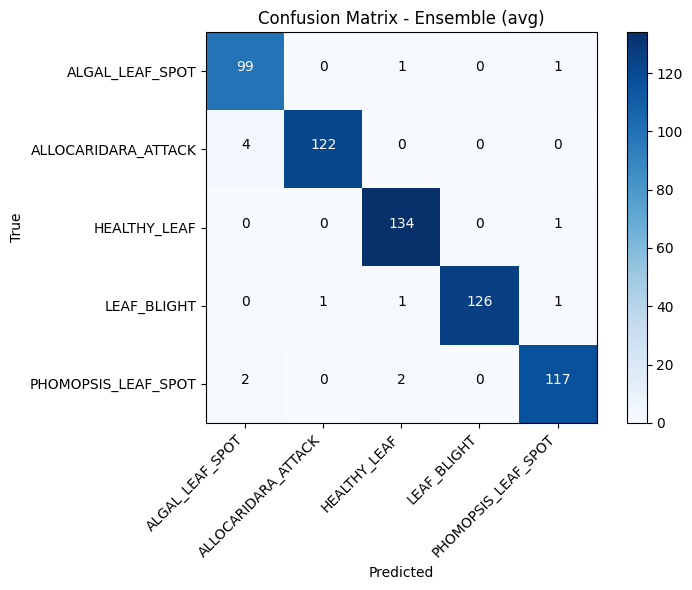

In [57]:
# Cell: Display ensemble confusion matrix
from IPython.display import Image, display
p = os.path.join(out_dir, "cm_images", "confusion_ensemble_avg.png")
if os.path.exists(p):
    display(Image(p))
else:
    print("Ensemble confusion matrix not found:", p)


# EfficientNetV2

In [61]:
import torch

model_path = "transferLearning_aug/efficientNetV2/efficientnetv2_checkpoint_fold2.pt"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# โหลด checkpoint Fabric
checkpoint = torch.load(model_path, map_location=device)

# เข้าถึงโมเดลตรง ๆ
if hasattr(checkpoint, 'module'):
    model = checkpoint.module  # ใช้โมเดลจาก checkpoint เลย
else:
    model = checkpoint

model.eval()
model.to(device)


C:\Users\ahmad\AppData\Local\Temp\ipykernel_19396\2242994819.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)


EfficientNet(
  (conv_stem): Conv2dSame(3, 24, kernel_size=(3, 3), stride=(2, 2), bias=False)
  (bn1): BatchNormAct2d(
    24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): ConvBnAct(
        (conv): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNormAct2d(
          24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (drop_path): Identity()
      )
      (1): ConvBnAct(
        (conv): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNormAct2d(
          24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (drop_path):

In [62]:
from fvcore.nn import FlopCountAnalysis
import torch

# สร้าง input dummy (batch=1, 3 channels, 224x224)
dummy_input = torch.randn(1, 3, 224, 224).to(device)

# วัด FLOPs
flops = FlopCountAnalysis(model, dummy_input)
print("FLOPs per forward:", flops.total())  # จำนวน FLOPs
print("GFLOPs per forward:", flops.total() / 1e9)


Unsupported operator aten::div encountered 10 time(s)
Unsupported operator aten::ceil encountered 10 time(s)
Unsupported operator aten::sub encountered 40 time(s)
Unsupported operator aten::mul encountered 50 time(s)
Unsupported operator aten::add encountered 55 time(s)
Unsupported operator aten::pad encountered 5 time(s)
Unsupported operator aten::silu_ encountered 102 time(s)
Unsupported operator aten::mean encountered 30 time(s)
Unsupported operator aten::sigmoid encountered 30 time(s)


FLOPs per forward: 2873001536
GFLOPs per forward: 2.873001536


In [63]:
import time

iters = 40
times = []
with torch.no_grad():
    for _ in range(iters):
        start = time.time()
        _ = model(dummy_input)
        torch.cuda.synchronize() if device.type == "cuda" else None
        end = time.time()
        times.append(end - start)

avg_time = sum(times) / iters
gflops = flops.total() / 1e9
throughput = gflops / avg_time

print("Average forward time (s):", avg_time)
print("GFLOPs/s:", throughput)


Average forward time (s): 0.02875446677207947
GFLOPs/s: 99.91496482173262
